# Setup

In [ ]:
import os
import glob
import yaml
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_prep
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_prep
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_prep
from IPython.display import display

seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Data Prep

In [ ]:
yaml_files = glob.glob('/kaggle/input/**/*.yaml', recursive=True)
yaml_path = None
data_info = None

for yf in yaml_files:
    with open(yf, 'r') as f:
        try:
            content = yaml.safe_load(f)
            if content and 'names' in content:
                yaml_path = yf
                data_info = content
                break
        except yaml.YAMLError:
            pass

if yaml_path is None:
    raise FileNotFoundError("Could not find a YAML file with class names in /kaggle/input")

dataset_dir = os.path.dirname(yaml_path)
print(f"Found dataset at: {dataset_dir}")

class_names = data_info['names']
if isinstance(class_names, dict):
    class_names = [class_names[k] for k in sorted(class_names.keys())]
num_classes = len(class_names)
print(f"Classes ({num_classes}): {class_names}")

Found dataset at: /kaggle/input/datasets/caferfatihgltekin/air-defense-object-detection-dataset-yolov8/Air_Defense_Object_Detection_Dataset_(YOLOv8)
Classes (4): ['f16', 'helicopter', 'quadcopter', 'rocket']


In [ ]:
image_files = glob.glob(os.path.join(dataset_dir, '**', '*.jpg'), recursive=True) + \
              glob.glob(os.path.join(dataset_dir, '**', '*.png'), recursive=True)

valid_images = []
valid_labels = []

for img_path in image_files: 
    label_path = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    if os.path.exists(label_path):
        valid_images.append(img_path)
        valid_labels.append(label_path)

train_img, temp_img, train_lbl, temp_lbl = train_test_split(valid_images, valid_labels, test_size=0.3, random_state=seed)
val_img, test_img, val_lbl, test_lbl = train_test_split(temp_img, temp_lbl, test_size=0.5, random_state=seed)

print(f"Images -> Train: {len(train_img)}, Val: {len(val_img)}, Test: {len(test_img)}")

Images -> Train: 6318, Val: 1354, Test: 1355


In [ ]:
output_dir = '/kaggle/working/dataset'

def process_and_save_crops(img_paths, lbl_paths, split_name):
    split_dir = os.path.join(output_dir, split_name)
    for c in class_names:
        os.makedirs(os.path.join(split_dir, c), exist_ok=True)
        
    crop_count = 0
    for img_path, lbl_path in zip(img_paths, lbl_paths):
        img = cv2.imread(img_path)
        if img is None: continue
        h, w, _ = img.shape
        
        with open(lbl_path, 'r') as f:
            lines = f.readlines()
            
        for i, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) < 5: continue
                
            class_id = int(float(parts[0]))
            if class_id >= len(class_names): continue
            class_name = class_names[class_id]
            
            x_center, y_center, width, height = map(float, parts[1:5])
            
            x1 = int((x_center - width / 2) * w)
            y1 = int((y_center - height / 2) * h)
            x2 = int((x_center + width / 2) * w)
            y2 = int((y_center + height / 2) * h)
            
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)
            if x2 <= x1 or y2 <= y1: continue
                
            crop = img[y1:y2, x1:x2]
            crop = cv2.resize(crop, (224, 224))
            
            base_name = os.path.basename(img_path).rsplit('.', 1)[0]
            save_path = os.path.join(split_dir, class_name, f"{base_name}_crop_{i}.jpg")
            cv2.imwrite(save_path, crop)
            crop_count += 1
            
    print(f"Saved {crop_count} crops for {split_name}")

process_and_save_crops(train_img, train_lbl, 'train')
process_and_save_crops(val_img, val_lbl, 'val')
process_and_save_crops(test_img, test_lbl, 'test')

Saved 7453 crops for train
Saved 1603 crops for val
Saved 1598 crops for test


In [ ]:
train_dir = os.path.join(output_dir, 'train')
val_dir = os.path.join(output_dir, 'val')
test_dir = os.path.join(output_dir, 'test')
batch_size = 32

def create_gens(prep_func=None, rescale=None):
    train_datagen = ImageDataGenerator(
        rescale=rescale,
        preprocessing_function=prep_func,
        rotation_range=20,
        horizontal_flip=True,
        zoom_range=0.2,
        brightness_range=[0.8, 1.2]
    )
    test_datagen = ImageDataGenerator(rescale=rescale, preprocessing_function=prep_func)
    
    train_g = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical', shuffle=True, seed=seed)
    val_g = test_datagen.flow_from_directory(val_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical', shuffle=False)
    test_g = test_datagen.flow_from_directory(test_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical', shuffle=False)
    
    return train_g, val_g, test_g

print("Creating Base CNN generators...")
train_gen_base, val_gen_base, test_gen_base = create_gens(rescale=1./255)

print("\nCreating VGG16 generators...")
train_gen_vgg, val_gen_vgg, test_gen_vgg = create_gens(prep_func=vgg_prep)

print("\nCreating ResNet50 generators...")
train_gen_resnet, val_gen_resnet, test_gen_resnet = create_gens(prep_func=resnet_prep)

print("\nCreating MobileNetV2 generators...")
train_gen_mobilenet, val_gen_mobilenet, test_gen_mobilenet = create_gens(prep_func=mobilenet_prep)

train_classes = train_gen_base.classes
print("\nClass distribution in training set:")
for i, count in enumerate(np.bincount(train_classes)):
    print(f"{class_names[i]}: {count}")

class_weights = compute_class_weight('balanced', classes=np.unique(train_classes), y=train_classes)
class_weight_dict = dict(enumerate(class_weights))
print("\nComputed class weights:", class_weight_dict)

callbacks = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
epochs = 30
hyperparams_data = []

def record_hp(name, model, lr, dropout, epochs_trained):
    trainable_params = int(np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]))
    hyperparams_data.append({
        'Model': name,
        'Input Size': '224x224x3',
        'Batch Size': batch_size,
        'Optimizer': 'Adam',
        'Learning Rate': lr,
        'Dropout Rate': dropout,
        'Loss Function': 'categorical_crossentropy',
        'Epochs Trained': epochs_trained,
        'Trainable Parameters': trainable_params
    })

def plot_curves(history, name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'{name} - Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'{name} - Loss')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{name}_training_curves.png')
    plt.show()

Creating Base CNN generators...
Found 7453 images belonging to 4 classes.
Found 1603 images belonging to 4 classes.
Found 1598 images belonging to 4 classes.

Creating VGG16 generators...
Found 7453 images belonging to 4 classes.
Found 1603 images belonging to 4 classes.
Found 1598 images belonging to 4 classes.

Creating ResNet50 generators...
Found 7453 images belonging to 4 classes.
Found 1603 images belonging to 4 classes.
Found 1598 images belonging to 4 classes.

Creating MobileNetV2 generators...
Found 7453 images belonging to 4 classes.
Found 1603 images belonging to 4 classes.
Found 1598 images belonging to 4 classes.

Class distribution in training set:
f16: 2350
helicopter: 1318
quadcopter: 1755
rocket: 2030

Computed class weights: {0: np.float64(0.7928723404255319), 1: np.float64(1.4136949924127467), 2: np.float64(1.0616809116809116), 3: np.float64(0.9178571428571428)}


# Base CNN

--- Hyperparameter Grid Search ---
Testing LR: 0.001, Dropout: 0.3...


I0000 00:00:1789470478.375709      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789470478.378617      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
2026-09-15 11:08:06.598486: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 11:08:06.747636: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1789470490.008994     156 device_compiler.h:196] Compiled cluster using XLA!

Testing LR: 0.001, Dropout: 0.5...
Testing LR: 0.0001, Dropout: 0.3...
Testing LR: 0.0001, Dropout: 0.5...

Grid Search Results:


,Learning Rate,Dropout,Val Accuracy
0,0.0010,0.3,0.550842
1,0.0010,0.5,0.543356
2,0.0001,0.3,0.497817
3,0.0001,0.5,0.495321



Selected Best Hyperparameters -> LR: 0.001, Dropout: 0.3

--- Full Training ---


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,828 (1.61 MB)

 Trainable params: 421,828 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 99s 405ms/step - accuracy: 0.4257 - loss: 1.2190 - val_accuracy: 0.4735 - val_loss: 1.1314
Epoch 2/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 91s 388ms/step - accuracy: 0.4821 - loss: 1.1248 - val_accuracy: 0.5078 - val_loss: 1.0739
Epoch 3/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 91s 391ms/step - accuracy: 0.5019 - loss: 1.0892 - val_accuracy: 0.5122 - val_loss: 1.1066
Epoch 4/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 93s 399ms/step - accuracy: 0.5213 - loss: 1.0542 - val_accuracy: 0.5053 - val_loss: 1.0698
Epoch 5/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 91s 392ms/step - accuracy: 0.5379 - loss: 1.0241 - val_accuracy: 0.5521 - val_loss: 0.9620
Epoch 6/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 93s 399ms/step - accuracy: 0.5484 - loss: 0.9887 - val_accuracy: 0.5483 - val_loss: 0.9269
Epoch 7/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 92s 396ms/step - accuracy: 0.5619 - loss: 0.9643 - val_accuracy: 0.5309 - val_loss: 0.9850
Epoch 8/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 91s 390ms/step - accuracy: 0.5814 - loss: 0

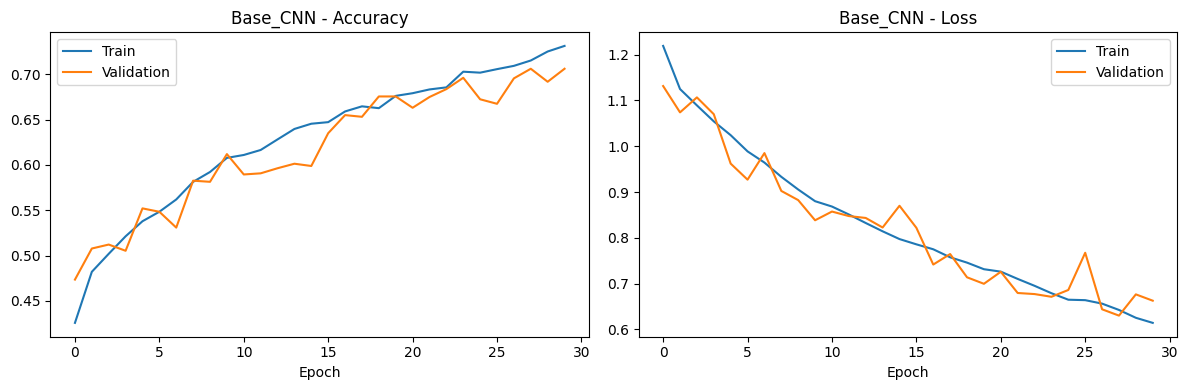

In [ ]:
print("--- Hyperparameter Grid Search ---")
grid_results = []
best_val_acc = 0
best_lr = 1e-3
best_do = 0.5

for lr in [1e-3, 1e-4]:
    for do in [0.3, 0.5]:
        print(f"Testing LR: {lr}, Dropout: {do}...")
        
        temp_model = Sequential([
            Input(shape=(224, 224, 3)),
            Conv2D(32, (3, 3), activation='relu'),
            MaxPooling2D(2, 2),
            Conv2D(64, (3, 3), activation='relu'),
            MaxPooling2D(2, 2),
            Conv2D(128, (3, 3), activation='relu'),
            MaxPooling2D(2, 2),
            Conv2D(256, (3, 3), activation='relu'),
            MaxPooling2D(2, 2),
            GlobalAveragePooling2D(),
            Dense(128, activation='relu'),
            Dropout(do),
            Dense(num_classes, activation='softmax')
        ])
        
        temp_model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])
        
        history_temp = temp_model.fit(
            train_gen_base, 
            validation_data=val_gen_base, 
            epochs=5, 
            class_weight=class_weight_dict, 
            verbose=0
        )
        
        val_acc = history_temp.history['val_accuracy'][-1]
        grid_results.append({'Learning Rate': lr, 'Dropout': do, 'Val Accuracy': val_acc})
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_lr = lr
            best_do = do

df_grid = pd.DataFrame(grid_results)
print("\nGrid Search Results:")
display(df_grid)
print(f"\nSelected Best Hyperparameters -> LR: {best_lr}, Dropout: {best_do}\n")

print("--- Full Training ---")
base_cnn = Sequential([
    Input(shape=(224, 224, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(best_do),
    Dense(num_classes, activation='softmax')
], name='Base_CNN')

base_cnn.compile(optimizer=Adam(learning_rate=best_lr), loss='categorical_crossentropy', metrics=['accuracy'])
base_cnn.summary()

history_cnn = base_cnn.fit(
    train_gen_base, 
    validation_data=val_gen_base, 
    epochs=epochs, 
    class_weight=class_weight_dict, 
    callbacks=callbacks
)

plot_curves(history_cnn, 'Base_CNN')
record_hp('Base_CNN', base_cnn, best_lr, best_do, len(history_cnn.history['loss']))

# VGG16

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 141s 528ms/step - accuracy: 0.6120 - loss: 1.2349 - val_accuracy: 0.7467 - val_loss: 0.5646
Epoch 2/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 105s 452ms/step - accuracy: 0.7186 - loss: 0.6742 - val_accuracy: 0.7573 - val_loss: 0.4800
Epoch 3/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 107s 457ms/step - accuracy: 0.7469 - loss: 0.5958 - val_accuracy: 0.7873 - val_loss: 0.4504
Epoch 4/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 105s 449ms/step - accuracy: 0.7616 - loss: 0.5480 - val_accuracy: 0.7754 - val_loss: 0.4295
Epoch 5/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 106s 453ms/step - accuracy: 0.7821 - loss: 0.5064 - val_accuracy: 0.7954 - val_loss: 0.4196
Epoch 6/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 105s 450ms/step - accuracy: 0.7855 - loss: 0.4972 - val_accuracy: 0.7798 - val_loss: 0.4293
Epoch 7/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 105s 452ms/step - accuracy: 0.7940 - loss: 0.4690 - val_accuracy: 0.8222 - val_loss: 0.3860
Epoch 8/30
233/233 ━━━━━━

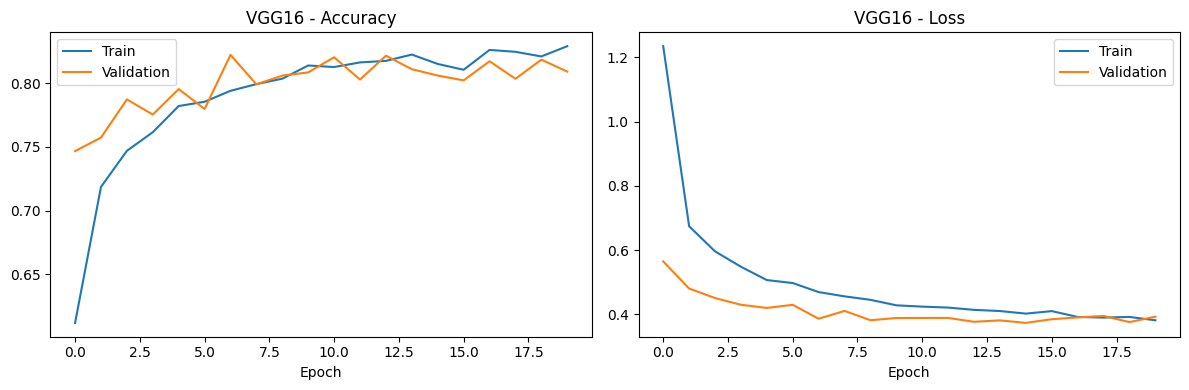

In [ ]:
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg_base.trainable = False

x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
preds = Dense(num_classes, activation='softmax')(x)

vgg_model = Model(inputs=vgg_base.input, outputs=preds, name='VGG16_TL')
vgg_model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

history_vgg = vgg_model.fit(
    train_gen_vgg, 
    validation_data=val_gen_vgg, 
    epochs=epochs, 
    class_weight=class_weight_dict, 
    callbacks=callbacks
)

plot_curves(history_vgg, 'VGG16')
record_hp('VGG16', vgg_model, 1e-3, 0.5, len(history_vgg.history['loss']))

# ResNet50

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 123s 472ms/step - accuracy: 0.7138 - loss: 0.7110 - val_accuracy: 0.8022 - val_loss: 0.4159
Epoch 2/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 98s 422ms/step - accuracy: 0.7841 - loss: 0.5172 - val_accuracy: 0.8129 - val_loss: 0.3922
Epoch 3/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 98s 420ms/step - accuracy: 0.7986 - loss: 0.4667 - val_accuracy: 0.8172 - val_loss: 0.3824
Epoch 4/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 98s 421ms/step - accuracy: 0.8109 - loss: 0.4452 - val_accuracy: 0.8222 - val_loss: 0.3753
Epoch 5/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 98s 422ms/step - accuracy: 0.8095 - loss: 0.4250 - val_accuracy: 0.8247 - val_loss: 0.3584
Epoch 6/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 98s 422ms/step - accuracy: 0.8193 - loss: 0.4141 - val_accuracy: 0.8216 - val_loss: 0.3576
Epoch 7/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 98s 421ms/step - accuracy: 0.8183 - loss: 0.4081 - val_accuracy: 0.8241 - val_loss: 0.3488
Epoch 8/30
233/233 ━━━━━━━━━━━━

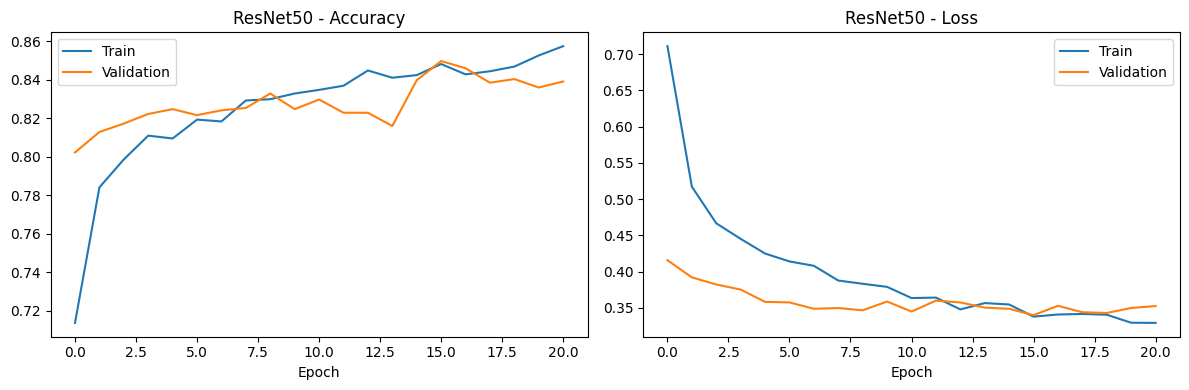

In [ ]:
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
resnet_base.trainable = False

x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
preds = Dense(num_classes, activation='softmax')(x)

resnet_model = Model(inputs=resnet_base.input, outputs=preds, name='ResNet50_TL')
resnet_model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

history_resnet = resnet_model.fit(
    train_gen_resnet, 
    validation_data=val_gen_resnet, 
    epochs=epochs, 
    class_weight=class_weight_dict, 
    callbacks=callbacks
)

plot_curves(history_resnet, 'ResNet50')
record_hp('ResNet50', resnet_model, 1e-3, 0.5, len(history_resnet.history['loss']))

# MobileNetV2

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30


2026-09-15 13:36:40.642303: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 13:36:40.781077: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


180/233 ━━━━━━━━━━━━━━━━━━━━ 20s 382ms/step - accuracy: 0.5935 - loss: 0.9909

2026-09-15 13:38:01.594293: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 13:38:01.731323: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.6140 - loss: 0.9368

2026-09-15 13:38:39.129261: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 13:38:39.265736: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


233/233 ━━━━━━━━━━━━━━━━━━━━ 136s 508ms/step - accuracy: 0.6907 - loss: 0.7367 - val_accuracy: 0.7760 - val_loss: 0.4874
Epoch 2/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 90s 387ms/step - accuracy: 0.7584 - loss: 0.5631 - val_accuracy: 0.8010 - val_loss: 0.4414
Epoch 3/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 92s 393ms/step - accuracy: 0.7774 - loss: 0.5088 - val_accuracy: 0.7998 - val_loss: 0.4298
Epoch 4/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 91s 391ms/step - accuracy: 0.7923 - loss: 0.4827 - val_accuracy: 0.7935 - val_loss: 0.4168
Epoch 5/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 92s 394ms/step - accuracy: 0.8057 - loss: 0.4576 - val_accuracy: 0.7854 - val_loss: 0.4308


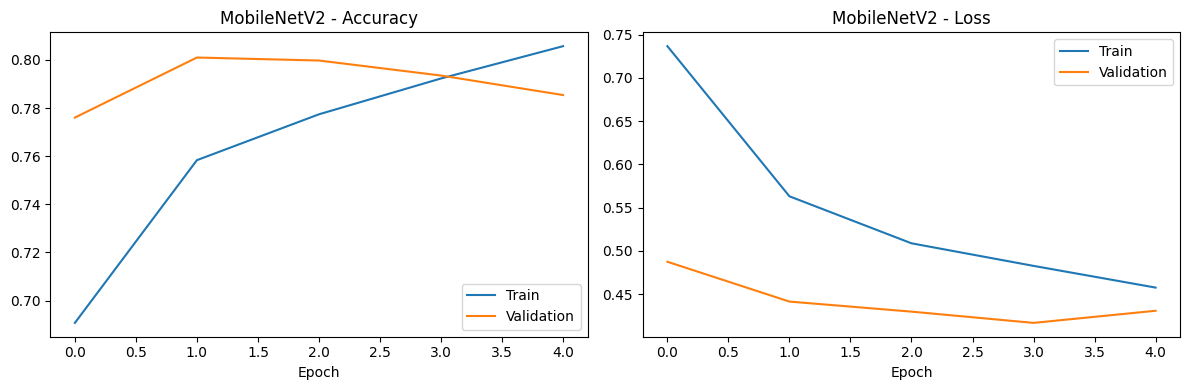

In [ ]:
mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
mobilenet_base.trainable = False

x = mobilenet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
preds = Dense(num_classes, activation='softmax')(x)

mobilenet_model = Model(inputs=mobilenet_base.input, outputs=preds, name='MobileNetV2_TL')
mobilenet_model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

history_mobilenet = mobilenet_model.fit(
    train_gen_mobilenet, 
    validation_data=val_gen_mobilenet, 
    epochs=epochs, 
    class_weight=class_weight_dict, 
    callbacks=callbacks
)

plot_curves(history_mobilenet, 'MobileNetV2')
record_hp('MobileNetV2', mobilenet_model, 1e-3, 0.5, len(history_mobilenet.history['loss']))

# Evaluation & Comparison


Evaluating Base_CNN...
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step


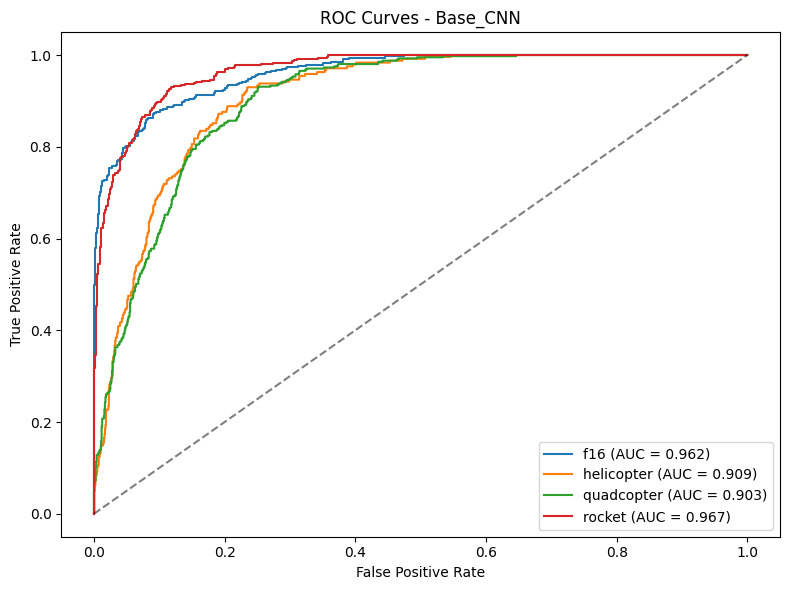


Evaluating VGG16...
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 509ms/step


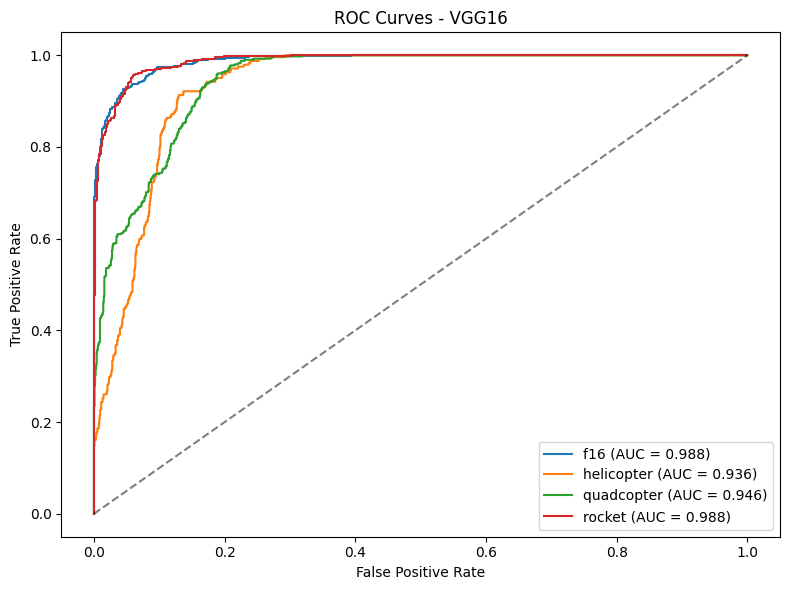


Evaluating ResNet50...
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 214ms/step


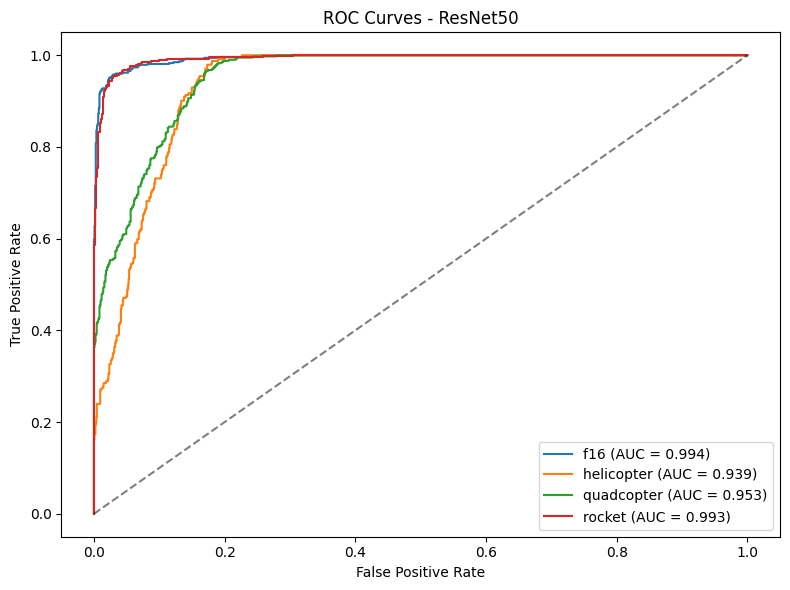


Evaluating MobileNetV2...
48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

2026-09-15 13:45:53.141914: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 13:45:53.280432: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 287ms/step


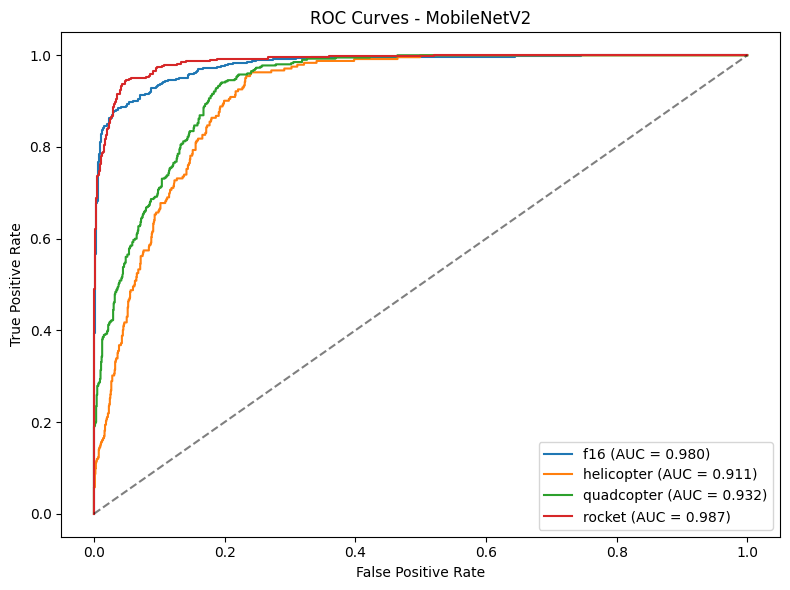


--- Final Hyperparameters ---


,Model,Input Size,Batch Size,Optimizer,Learning Rate,Dropout Rate,Loss Function,Epochs Trained,Trainable Parameters
0,Base_CNN,224x224x3,32,Adam,0.001,0.3,categorical_crossentropy,30,421828
1,VGG16,224x224x3,32,Adam,0.001,0.5,categorical_crossentropy,20,66180
2,ResNet50,224x224x3,32,Adam,0.001,0.5,categorical_crossentropy,21,262788
3,MobileNetV2,224x224x3,32,Adam,0.001,0.5,categorical_crossentropy,5,164484



--- Final Evaluation Metrics ---


,Model,Accuracy,Macro Precision,Macro Recall (Sensitivity),Macro F1,Macro Specificity,ROC-AUC (OVR)
0,Base_CNN,0.737797,0.720232,0.727776,0.719066,0.914868,0.935060
1,VGG16,0.817897,0.795173,0.802854,0.794931,0.941146,0.964594
2,ResNet50,0.842303,0.809126,0.796058,0.799162,0.948146,0.969576
3,MobileNetV2,0.791615,0.771816,0.779046,0.765194,0.933879,0.952512


In [ ]:
models_info = [
    ('Base_CNN', base_cnn, test_gen_base), 
    ('VGG16', vgg_model, test_gen_vgg),
    ('ResNet50', resnet_model, test_gen_resnet), 
    ('MobileNetV2', mobilenet_model, test_gen_mobilenet)
]

results = []
y_true = test_gen_base.classes
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=num_classes)

for name, model, test_g in models_info:
    print(f"\nEvaluating {name}...")
    test_g.reset()
    y_pred_prob = model.predict(test_g, steps=len(test_g))
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    acc = report['accuracy']
    macro_prec = report['macro avg']['precision']
    macro_rec = report['macro avg']['recall']
    macro_f1 = report['macro avg']['f1-score']
    
    cm = confusion_matrix(y_true, y_pred)
    sensitivities, specificities = [], []
    
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fp + fn)
        
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        
    macro_sens = np.mean(sensitivities)
    macro_spec = np.mean(specificities)
    
    roc_auc = roc_auc_score(y_true_onehot, y_pred_prob, multi_class='ovr')
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Macro Precision': macro_prec,
        'Macro Recall (Sensitivity)': macro_sens,
        'Macro F1': macro_f1,
        'Macro Specificity': macro_spec,
        'ROC-AUC (OVR)': roc_auc
    })
    
    plt.figure(figsize=(8, 6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
        class_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {class_auc:.3f})')
        
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.title(f'ROC Curves - {name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{name}_roc_curves.png')
    plt.show()

df_hp = pd.DataFrame(hyperparams_data)
df_hp.to_csv('/kaggle/working/hyperparameters.csv', index=False)

df_results = pd.DataFrame(results)
df_results.to_csv('/kaggle/working/model_comparison.csv', index=False)

print("\n--- Final Hyperparameters ---")
display(df_hp)

print("\n--- Final Evaluation Metrics ---")
display(df_results)